

# Introduction
Welcome to todays lab session where we will focus on the details of training a two-layer neural network presented in the lectures and deploying it on a real dataset using Python/Numpy.

The easiest way to complete this session is to log into a Google account and save a copy to your google drive. Alternatively, you could save this document to your machine and open as a Jupyter notebook. 


# Two-layer NNs model (from the lectures)

In the lectures 3 and 4, we have studied a two layer MLP network with a sigmoid non-linear activation and the real valued outputs. 


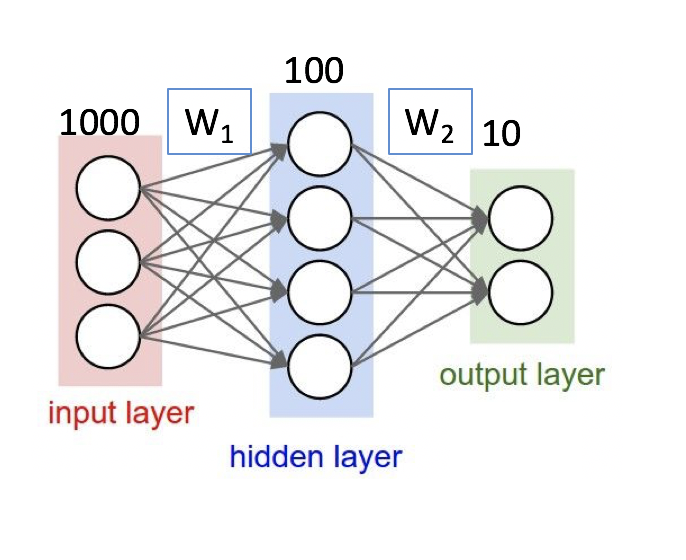

We have derived the expressions for analytical gradients using backpropagation on computational graphs:

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import randn

#define the network
N,D_in, H, D_out = 64, 1000, 100, 10
W1,W2 = randn(H, D_in)*0.1, randn(D_out, H)*0.1
x,y = randn(D_in, N), randn(D_out,N)

plotloss=[]
#Perform training using gradient descent algorithm (with N samples):
for t in range(2000):
  #forward
	h = 1 / (1 + np.exp(-np.dot(W1,x))) 
	y_pred = np.dot(W2,h)
	loss = np.square(y_pred - y).sum()
	#print(t,loss)
	plotloss.append(loss)
	
  #gradient computation with backpropagation
	grad_y_pred = 2.*(y_pred - y)
	grad_W2 = np.dot(grad_y_pred,h.T)
	grad_h = np.dot(W2.T,grad_y_pred)
	grad_W1 = np.dot(grad_h * h*(1-h),x.T)
 
  #gradient descent step
	W1 -=1e-4 * grad_W1
	W2 -=1e-4 * grad_W2

**Task**: 
1. Modify the code to account for bias terms in the hidden and output layers. Start with initialisation of the bias terms (take care of the dimensions) and proceed with forward and backward passes.

Tips: 

initialise the bias terms: 
```
	b1, b2 = 
```
modify the forward pass by adding the biases in these terms:
```
	h = 1 / (1 + np.exp(-np.dot(W1,x))) 
	y_pred = np.dot(W2,h)
```
modify the backward pass ( e.g. by using a sum node in the computation graph where the bias is added):
```
	grad_b2 = upstream gradient x local gradients
	grad_b1 = upstream gradient x local gradients
``` 
modify gradient descent optimisation:
```
    W1 -=1e-4 * grad_W1
    W2 -=1e-4 * grad_W2
    b1 -=1e-4 * grad_b1
    b2 -=1e-4 * grad_b2
```
Plot the loss curves:

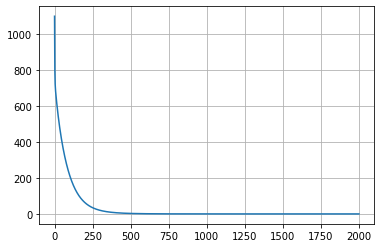

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.plot(range(2000),np.array(plotloss))
plt.grid()
plt.show()



**Task 2 (extra):**

Modify the non-linear activation function to be a ReLU. 


#SOLUTIONS

with sigmoid non-linearity:

0 1622.935195058802
100 217.57411434888027
200 71.88061024492278
300 26.065092773983913
400 10.096491772369102
500 4.129722198957802
600 1.776728900147241
700 0.7994127073401003
800 0.37377117352525213
900 0.1805469615104308
1000 0.0896586526457614
1100 0.04559225939752469
1200 0.023665368751698192
1300 0.01250682041914649
1400 0.0067153120059480894
1500 0.0036565901190158956
1600 0.0020159449867083665
1700 0.0011237027411571097
1800 0.0006324678518377237
1900 0.00035904041174842104


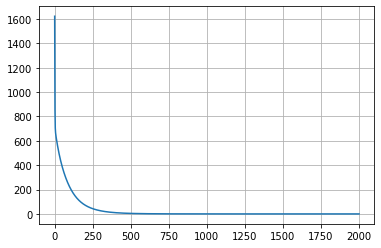

In [ ]:
#This code was written by V. Sharmanska. All rights reserved.
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import randn

#define the network
N,D_in, H, D_out = 64, 1000, 100, 10
W1,W2 = randn(H, D_in)*0.1, randn(D_out, H)*0.1
#initialise bias terms
b1, b2 = randn(H, 1), randn(D_out, 1)
x,y = randn(D_in, N), randn(D_out,N)

plotloss=[]
#Perform training using gradient descent algorithm:
for t in range(2000):
    #forward
    h = 1 / (1 + np.exp(- (np.dot(W1,x)+b1)))     #+b1 is equiv. to +np.dot(b1, np.ones((1,N))) 
    y_pred = np.dot(W2,h)+b2                      #+b2 is equiv. to +np.dot(b2, np.ones((1,N)))
    loss = np.square(y_pred - y).sum()
    if (t%100 == 0):
        print(t,loss)
    plotloss.append(loss)

    #gradient computation with backpropagation
    grad_y_pred = 2.*(y_pred - y)
    grad_W2 = np.dot(grad_y_pred,h.T)
    grad_b2 = np.dot(grad_y_pred,np.ones((1,N)).T)           #equiv. grad_b2 = np.sum(grad_y_pred, axis=1).reshape(b2.shape)
    grad_h = np.dot(W2.T,grad_y_pred)

    grad_W1 = np.dot(grad_h * h*(1-h),x.T)
    grad_b1 = np.dot(grad_h * h*(1-h),np.ones((1,N)).T)      #equiv. grad_b1 = np.sum(grad_h * h*(1-h), axis=1).reshape(b1.shape)

    #gradient descent step
    W1 -=1e-4 * grad_W1
    W2 -=1e-4 * grad_W2
    b1 -=1e-4 * grad_b1
    b2 -=1e-4 * grad_b2

plt.plot(range(1,len(plotloss)+1),np.array(plotloss))
plt.grid()
plt.show()

with ReLU non-linearity

0 4527.456838271649
50 5.940191995719897
100 0.16915251847800616
150 0.007046679839208382
200 0.0003608853765450405
250 2.153007019232059e-05
300 1.436298507778565e-06
350 1.0352232133359235e-07
400 7.85717235829741e-09
450 6.171249286095008e-10
500 4.95963475203947e-11
550 4.0494381481279985e-12
600 3.343496157663632e-13
650 2.7834241645410838e-14
700 2.3315691762287162e-15
750 1.9624913206554584e-16
800 1.6581943393680377e-17
850 1.405447989193813e-18
900 1.1943452258799373e-19
950 1.017157682748928e-20


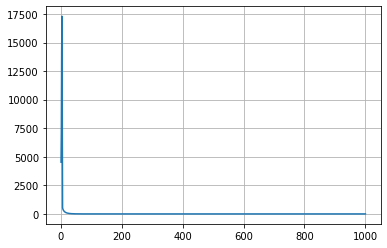

In [ ]:
#This code was written by V. Sharmanska. All rights reserved.
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import randn

#define the network
N,D_in, H, D_out = 64, 1000, 100, 10
W1,W2 = randn(H, D_in)*0.1, randn(D_out, H)*0.1
#initialise bias terms
b1, b2 = randn(H, 1), randn(D_out, 1)
x,y = randn(D_in, N), randn(D_out,N)

plotloss=[]
#Perform training using gradient descent algorithm (with N samples):
for t in range(1000):
    #forward
    h = np.maximum(np.dot(W1,x)+b1,0)     #+b1 is equiv. to +np.dot(b1, np.ones((1,N))) 
    y_pred = np.dot(W2,h)+b2              #+b2 is equiv. to +np.dot(b2, np.ones((1,N)))
    loss = np.square(y_pred - y).sum()
    if (t%50 == 0):
        print(t,loss)
    plotloss.append(loss)


    #gradient computation with backpropagation
    grad_y_pred = 2.*(y_pred - y)
    grad_W2 = np.dot(grad_y_pred,h.T)
    grad_b2 = np.dot(grad_y_pred,np.ones((1,N)).T)

    grad_h = np.dot(W2.T,grad_y_pred)
    
    grad_W1 = np.dot(grad_h* (h>0),x.T)               
    grad_b1 = np.dot(grad_h* (h>0),np.ones((1,N)).T)  

    #gradient descent step
    W1 -=1e-4 * grad_W1
    W2 -=1e-4 * grad_W2
    b1 -=1e-4 * grad_b1
    b2 -=1e-4 * grad_b2

plt.plot(range(1,len(plotloss)+1),np.array(plotloss))
plt.grid()
plt.show()